In [1]:
# 1. Imports y carga del dataset.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, RobustScaler
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_percentage_error, max_error, make_scorer, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import re
import polars as pl
from matplotlib.ticker import PercentFormatter
import pyarrow.parquet as pq
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from sklearn import svm



from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [2]:
#2. Carga del dataset.
df_train = pd.read_csv("Data/train.csv")
df_test = pd.read_csv("Data/test.csv")

In [3]:
#Funciones auxiliares

def compare_models(y_test, y_pred, models):
    mod= models
    acu = []
    kap = []
    f1 = []
    for pred in y_pred:
        acu.append(accuracy_score(y_test, pred))
        kap.append(cohen_kappa_score(y_test, pred))
        f1.append(f1_score(y_test, pred, average='macro'))

    return pd.DataFrame({
        "Model": mod,
        "Accuracy": acu,
        "kappa": kap,
        "f1_Score": f1
    })


def display_professional_eval(y_true, y_pred, cv_res):
    sns.set_theme(style="whitegrid")

    print("="*60)
    print(f"{'REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII':^60}")
    print("="*60)

    print(f"\n[ESTABILIDAD DEL MODELO - CROSS VALIDATION (K=5)]")
    print(f"  > Accuracy: {cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std() * 2:.4f}")
    print(f"  > F1-Macro: {cv_res['test_f1_macro'].mean():.4f} ± {cv_res['test_f1_macro'].std() * 2:.4f}")
    print(f"  > Kappa: {cohen_kappa_score(y_true, y_pred):.4f}")

    print(f"\n[DESEMPEÑO EN SET DE PRUEBA]")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax, values_format='d') # 'd' asegura números enteros

    plt.title('Confusion Matrix: Predicted vs Actual (Ordered)')
    plt.tight_layout()
    plt.show()

    plt.tight_layout()
    plt.show()

def plot_rf_importance(model, feature_names, top_n=20):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title("Top Feature Importances (Random Forest)")
    plt.xlabel("Importance")
    plt.show()

def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def num_correlation_classifier(df, target, threshold=0.0, sort_by_abs=True):
    corr = df.corr(numeric_only=True)[target].drop(target)
    corr_df = (
        corr.reset_index()
        .rename(columns={"index": "feature", target: "correlation"})
    )
    corr_df["direction"] = corr_df["correlation"].apply(
        lambda x: "positive" if x > 0 else "negative"
    )
    def classify_strength(c):
        c = abs(c)
        if c < 0.1:
            return "very weak"
        elif c < 0.3:
            return "weak"
        elif c < 0.5:
            return "moderate"
        elif c < 0.7:
            return "strong"
        else:
            return "very strong"
    corr_df["strength"] = corr_df["correlation"].apply(classify_strength)
    corr_df["abs_correlation"] = corr_df["correlation"].abs()
    corr_df = corr_df[corr_df["abs_correlation"] >= threshold]
    if sort_by_abs:
        corr_df = corr_df.sort_values("abs_correlation", ascending=False)
    else:
        corr_df = corr_df.sort_values("correlation", ascending=False)
    corr_df = corr_df.reset_index(drop=True)
    return corr_df


def num_analysis(df, target):
    corr = df.corr(numeric_only=True)
    if target in corr.columns:
        corr_y = corr[target].drop(target).sort_values()
        plt.figure(figsize=(10,10))
        corr_y.plot(kind='barh')
        plt.title(f'Correlation with {target}')
        plt.xlabel('Correlation')
        plt.ylabel('Features')
        plt.show()


def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def drop_features(X):
    X = X.drop(columns=unused_features, errors='ignore')
    return X


drop_features_transformer = FunctionTransformer(drop_features).set_output(transform="pandas")





In [4]:
#3 Se revisan tipo de variblaes y cantidad de nulos
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    floa

In [5]:
#4 Se revisa cantidad de nulos en variable objetivo y destribución de clases
print(df_train["sii"].isnull().value_counts(normalize=True))
print(df_train["sii"].value_counts(normalize=True))

sii
False    0.690909
True     0.309091
Name: proportion, dtype: float64
sii
0.0    0.582602
1.0    0.266813
2.0    0.138158
3.0    0.012427
Name: proportion, dtype: float64


In [6]:
#5 Se eliminan filas con nulos en variable objetivo para hacer entrenamiento supervisado
df_train = df_train[df_train["sii"].notnull()]
df_train["sii"] = df_train["sii"].astype(int)
df_train.shape

(2736, 82)

                                    Column     Empty  Not_Empty
50                            PAQ_A-Season  0.867325   0.132675
51                       PAQ_A-PAQ_A_Total  0.867325   0.132675
10            Physical-Waist_Circumference  0.823465   0.176535
17              Fitness_Endurance-Time_Sec  0.733918   0.266082
16             Fitness_Endurance-Time_Mins  0.733918   0.266082
15             Fitness_Endurance-Max_Stage  0.732822   0.267178
22                       FGC-FGC_GSND_Zone  0.684211   0.315789
24                        FGC-FGC_GSD_Zone  0.684211   0.315789
23                             FGC-FGC_GSD  0.681652   0.318348
21                            FGC-FGC_GSND  0.681287   0.318713
14                Fitness_Endurance-Season  0.539474   0.460526
53                       PAQ_C-PAQ_C_Total  0.473684   0.526316
52                            PAQ_C-Season  0.473684   0.526316
45                             BIA-BIA_ICW  0.337354   0.662646
38                             BIA-BIA_D

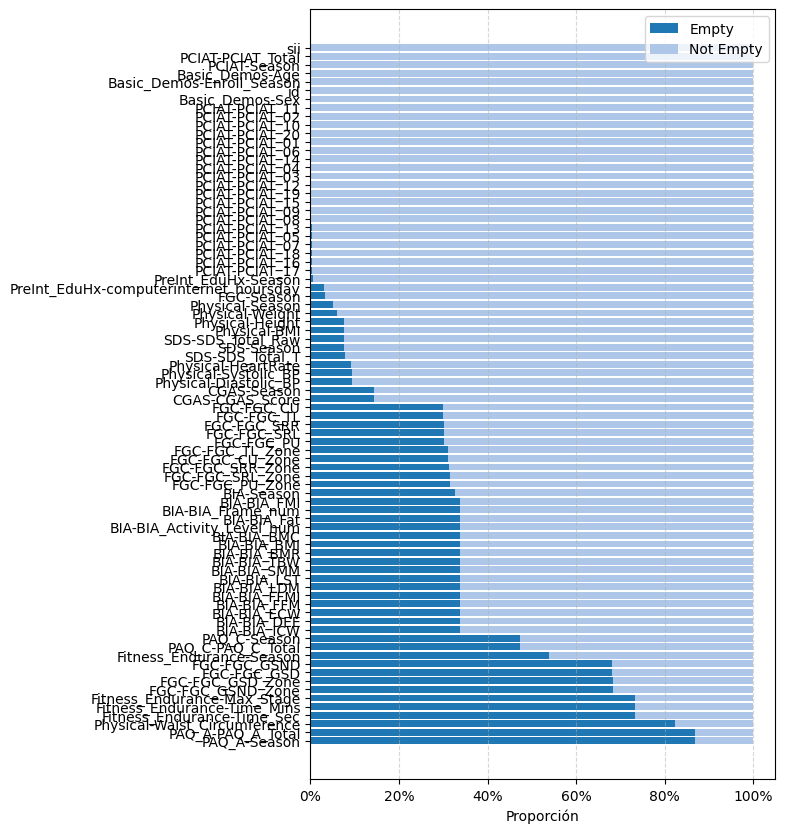

In [7]:
#6 Se revisa cantidad de nulos en cada variable con respecto de la vairable objetivo
empty = []

# A. Se calcula la proporción de valores nulos y no nulos para cada columna
for column in df_train.columns:
    empty.append((column, df_train[column].isnull().mean(), df_train[column].notnull().mean()))

# B. Se crea un DataFrame para visualizar los resultados
empty_df = pd.DataFrame(empty, columns=["Column", "Empty", "Not_Empty"])
empty_df = empty_df.sort_values(by="Empty", ascending=False)
print(empty_df.to_string())

# Se visualiza la proporción de valores nulos y no nulos para cada columna
missing_color = '#1f77b4'
available_color = '#aec7e8'

plt.figure(figsize=(6, 10))
y_pos = np.arange(len(empty_df))

plt.barh(y_pos, empty_df["Empty"], label="Empty", color=missing_color)
plt.barh(y_pos, empty_df["Not_Empty"], left=empty_df["Empty"], label="Not Empty", color=available_color)
plt.yticks(y_pos, empty_df["Column"])
plt.xlabel("Proporción")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend()


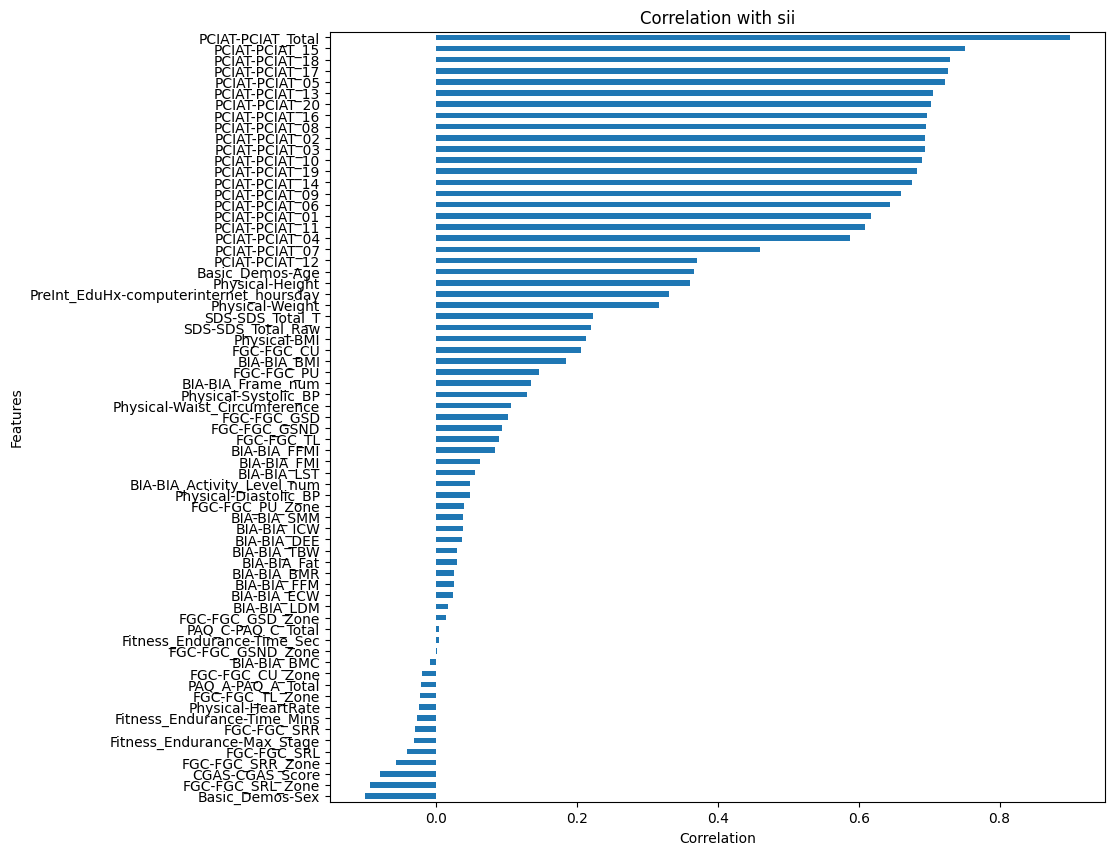

,feature,correlation,direction,strength,abs_correlation
0,PCIAT-PCIAT_Total,0.899681,positive,very strong,0.899681
1,PCIAT-PCIAT_15,0.750544,positive,very strong,0.750544
2,PCIAT-PCIAT_18,0.730237,positive,very strong,0.730237
3,PCIAT-PCIAT_17,0.726351,positive,very strong,0.726351
4,PCIAT-PCIAT_05,0.721932,positive,very strong,0.721932
5,PCIAT-PCIAT_13,0.704838,positive,very strong,0.704838
6,PCIAT-PCIAT_20,0.702466,positive,very strong,0.702466
7,PCIAT-PCIAT_16,0.697696,positive,strong,0.697696
8,PCIAT-PCIAT_08,0.695094,positive,strong,0.695094
9,PCIAT-PCIAT_02,0.694453,positive,strong,0.694453


In [8]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr = df_eda.corr()
target = "sii"
num_analysis(df_eda, target)
corr_table = num_correlation_classifier(
    df_eda,
    target,
    threshold=0.0
)
with pd.option_context(
    'display.max_rows', None,
    'display.expand_frame_repr', False
):
    display(corr_table)

In [9]:
df_train.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [10]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr_matrix = df_eda.corr()

corr_matrix_eda = df_eda.select_dtypes(include=[np.number]).corr()
top_corrs = get_top_correlations(corr_matrix_eda)
strong_corrs = top_corrs[top_corrs['Correlation'].abs() > 0.9]
with pd.option_context('display.max_rows', None, 'display.expand_frame_repr', False):
    display(strong_corrs)

,Feature 1,Feature 2,Correlation
0,BIA-BIA_BMR,BIA-BIA_FFM,1.000000
1,BIA-BIA_BMR,BIA-BIA_TBW,0.999652
2,BIA-BIA_FFM,BIA-BIA_TBW,0.999652
3,BIA-BIA_ECW,BIA-BIA_FFM,0.999182
4,BIA-BIA_BMR,BIA-BIA_ECW,0.999182
5,BIA-BIA_ECW,BIA-BIA_TBW,0.999021
6,BIA-BIA_FFM,BIA-BIA_LDM,0.998821
7,BIA-BIA_BMR,BIA-BIA_LDM,0.998821
8,BIA-BIA_ICW,BIA-BIA_TBW,0.998337
9,BIA-BIA_ECW,BIA-BIA_LDM,0.997658


In [ ]:
# 1. Escaneamos el dataset de parquet
df_parquet = pl.scan_parquet("Data/series_train.parquet")

# 2. Definimos las transformaciones y agregaciones
df_series = (
    df_parquet.with_columns([
        # Convertir nanosegundos a hora decimal
        (pl.col("time_of_day") / (1e9 * 3600)).alias("hour"),
    ])
    .with_columns([
        # Clasificar día vs noche
        pl.when((pl.col("hour") >= 6) & (pl.col("hour") < 20))
        .then(pl.lit("dia"))
        .otherwise(pl.lit("noche"))
        .alias("periodo")
    ])
    .with_columns([
        # Clasificar weekday vs weekend
        pl.when((pl.col("weekday") >= 1) & (pl.col("weekday") < 6))
        .then(pl.lit("weekday"))
        .otherwise(pl.lit("weekend"))
        .alias("dia_semana")
    ])
    .group_by("id")
    .agg([
        # Estadísticas básicas de ENMO
        pl.col("enmo").mean().alias("mean_enmo"),
        pl.col("enmo").std().alias("std_enmo"),
        
        # Proporción de inactividad y uso (flags)
        (pl.col("enmo") == 0).mean().alias("pct_inactive"),
        (pl.col("non-wear_flag") == 0).mean().alias("wear_ratio"),
        
        # Actividad por periodo (día vs noche)
        pl.col("enmo").filter(pl.col("periodo") == "dia").mean().alias("mean_day_activity"),
        pl.col("enmo").filter(pl.col("periodo") == "noche").mean().alias("mean_night_activity"),
        
        # Actividad por día de la semana (weekday vs weekend)
        pl.col("enmo").filter(pl.col("dia_semana") == "weekday").mean().alias("activity_weekday"),
        pl.col("enmo").filter(pl.col("dia_semana") == "weekend").mean().alias("activity_weekend"),
    ])
    .collect(streaming=True) 
    .to_pandas()
)

C:\Users\PAPELERIA GENESIS\AppData\Local\Temp\ipykernel_15764\837741976.py:42: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [12]:
df_train = df_train.merge(df_series, on="id", how="left")

In [13]:
# 5. Clasificación de features (SII).
unused_features = [
    # indicadores derivados
    'PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 
    'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 
    'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 
    'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 
    'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 
    'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 
    'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 
    'PCIAT-PCIAT_Total',


    # Variables con demasiados nulos
    'PAQ_A-Season',
    'PAQ_A-PAQ_A_Total',
    'Physical-Waist_Circumference',
    'Fitness_Endurance-Time_Sec',
    'Fitness_Endurance-Time_Mins',
    'Fitness_Endurance-Max_Stage',

    # identificadores
    'id',

    #Correlación muy elevada entre variables (Infomación redundante)
    'SDS-SDS_Total_Raw', 'BIA-BIA_DEE','BIA-BIA_ECW',
    'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM'
]

#---------------------------------------------------------------------------------------------------------

numeric_features = [
 'Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 
 'Physical-Weight', 'Physical-HeartRate', 'Physical-Diastolic_BP', 
 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 
 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_BMC', 
 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_FFM', 
 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
 'BIA-BIA_TBW', 'PAQ_C-PAQ_C_Total', 
 'SDS-SDS_Total_T', 'mean_enmo', 'std_enmo', 'pct_inactive', 
 'wear_ratio', 'mean_day_activity', 'mean_night_activity', 
 'activity_weekday', 'activity_weekend'
]

#---------------------------------------------------------------------------------------------------------

categorical_features = [
 'Basic_Demos-Enroll_Season', 'Basic_Demos-Sex', 'CGAS-Season', 
 'Physical-Season', 'FGC-Season', 'Fitness_Endurance-Season', 'BIA-Season', 
 'PAQ_C-Season', 'PreInt_EduHx-Season', 'SDS-Season',

]

#---------------------------------------------------------------------------------------------------------

ordinal_features = [
 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 
'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 
'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
 'PreInt_EduHx-computerinternet_hoursday'
]


In [14]:
X = df_train.drop(columns=["sii"])
y = df_train["sii"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [90]:
# 6. Definición de Pipelines de Imputación, Escalado y Encoding.
# a. Pipeline de limpieza.
dataset_cleaning_pipeline = Pipeline(steps=[
    ("drop_unused", drop_features_transformer)
])
# numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categóricas nominales
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ordinales (sin one hot)
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('ord', ord_pipeline, ordinal_features)
])
# e. Process PipeLine: une el pipeline de limpieza inicial con preprocessor.
process_pipeline = Pipeline(steps=[
    ("clean", dataset_cleaning_pipeline),
    ("preprocessor", preprocessor)
])
# f. Implementación del Pipeline.
X_train = process_pipeline.fit_transform(X_train_raw)
X_train = pd.DataFrame(
    X_train,
    columns=preprocessor.get_feature_names_out()
    )

X_test = process_pipeline.transform(X_test_raw)
X_test = pd.DataFrame(
    X_test,
    columns=preprocessor.get_feature_names_out()
    )

process_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_unused', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...0021D169D0FE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This

         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD DEL MODELO - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5229 ± 0.0405
  > F1-Macro: 0.3662 ± 0.0628
  > Kappa: 0.2016

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.78      0.63      0.69       336
           1       0.28      0.27      0.28       131
           2       0.28      0.42      0.33        72
           3       0.08      0.33      0.12         9

    accuracy                           0.51       548
   macro avg       0.35      0.41      0.36       548
weighted avg       0.58      0.51      0.54       548



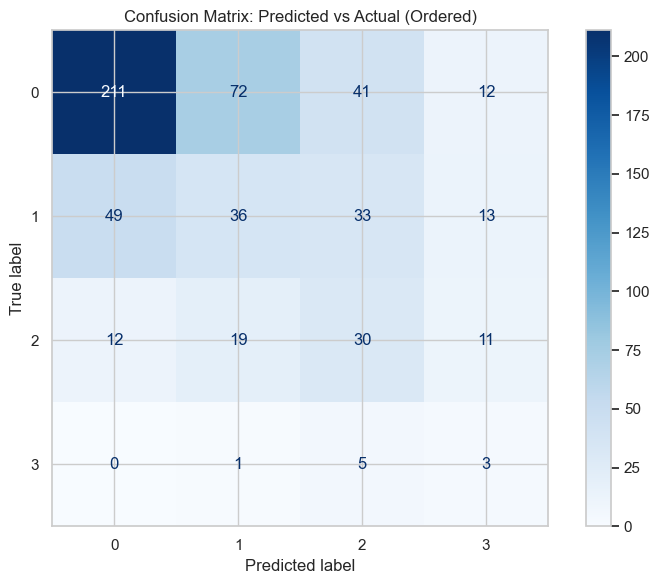

<Figure size 640x480 with 0 Axes>

In [91]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logistic_model.fit(X_train, y_train)
y_pres_lg = logistic_model.predict(X_test)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(logistic_model, X_train, y_train, cv=skf, scoring=scoring_metrics)

display_professional_eval(y_test, y_pres_lg, cv_results)

In [92]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, 25], # Controlado pero suficiente para aprender
    'min_samples_split': [2, 5], # Valores más bajos para permitir nodos pequeños
    'min_samples_leaf': [1, 2],  # Permitir que hojas de 1 o 2 ejemplos existan
    'class_weight': ['balanced', 'balanced_subsample'] # CLAVE para multiclase
}

rf_model = RandomForestClassifier(random_state=42)

grid = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("f1_macro CV:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
f1_macro CV: 0.35164036794771303


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD DEL MODELO - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5932 ± 0.0255
  > F1-Macro: 0.3519 ± 0.0255
  > Kappa: 0.1960

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.72      0.78      0.74       336
           1       0.31      0.31      0.31       131
           2       0.30      0.21      0.25        72
           3       1.00      0.11      0.20         9

    accuracy                           0.58       548
   macro avg       0.58      0.35      0.38       548
weighted avg       0.57      0.58      0.57       548



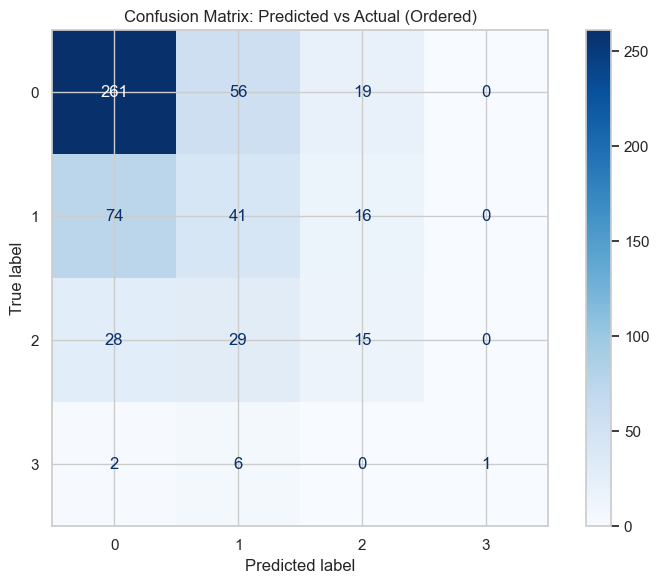

<Figure size 640x480 with 0 Axes>

In [118]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

cv_results_rf = cross_validate(
    model_rf,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics
)

display_professional_eval(
    y_test,
    y_pred_rf,
    cv_results_rf,
)


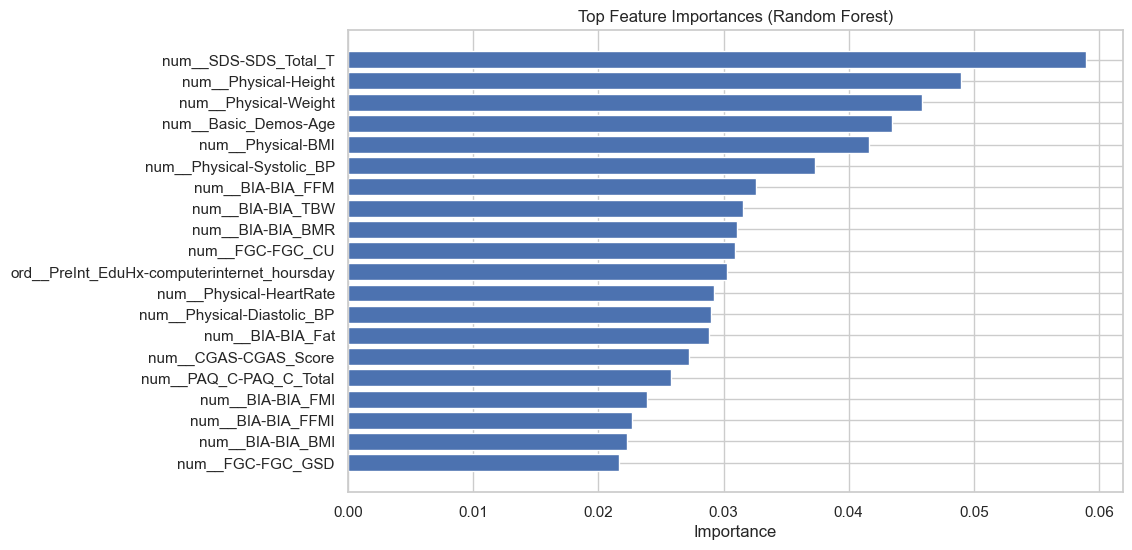

In [93]:
plot_rf_importance(model_rf, X_train.columns)

In [104]:
param_distr = {

    'n_estimators': [500, 400],
    'learning_rate': [0.01,0.1],
    'max_depth': [5, 7, 9],
    'max_delta_step': [1, 5],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.7],
    'colsample_bytree': [0., 0.9],    
    'gamma': [0.2, 0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10]
}


XB_model = XGBClassifier(random_state=42)

grid = RandomizedSearchCV(estimator=XB_model, param_distributions=param_distr,n_iter=40,cv=3, scoring='f1_macro',random_state=42, n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("f1_macro CV:", grid.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores parámetros: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'max_delta_step': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}
f1_macro CV: 0.3360237878321457


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD DEL MODELO - CROSS VALIDATION (K=5)]
  > Accuracy: 0.6092 ± 0.0130
  > F1-Macro: 0.3337 ± 0.0226
  > Kappa: 0.2740

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.79      0.72      0.76       336
           1       0.35      0.42      0.38       131
           2       0.27      0.26      0.27        72
           3       0.31      0.44      0.36         9

    accuracy                           0.59       548
   macro avg       0.43      0.46      0.44       548
weighted avg       0.61      0.59      0.60       548



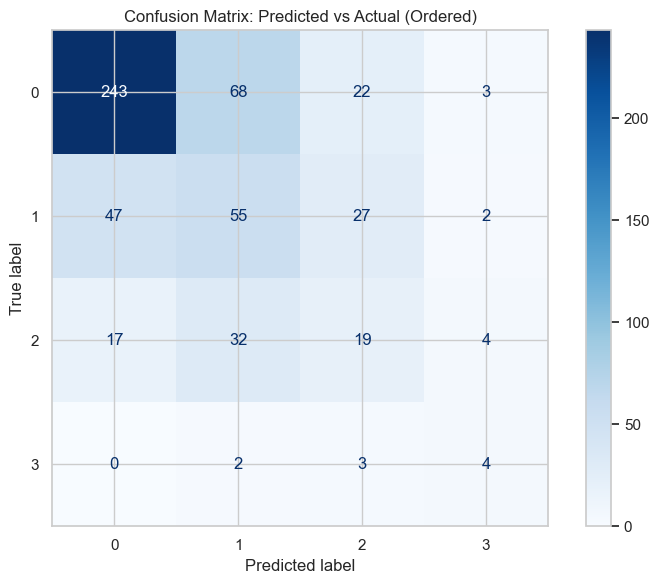

<Figure size 640x480 with 0 Axes>

In [113]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

sample_weights = y_train.map(class_weights)

model_XG = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    max_delta_step=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1,
)

model_XG.fit(X_train, y_train,sample_weight=sample_weights)
y_pred_XG = model_XG.predict(X_test)


cv_results_XG = cross_validate(
    model_XG,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics,
)

display_professional_eval(
    y_test,
    y_pred_XG,
    cv_results_XG,
)

In [117]:
param_grid = {
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 0.01, 0.1, 1],
}

svm_model = svm.SVC(kernel='rbf', random_state=42)

grid = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("f1_macro CV:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros: {'C': 10, 'gamma': 0.01}
f1_macro CV: 0.3426933022957643


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD DEL MODELO - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5416 ± 0.0237
  > F1-Macro: 0.3488 ± 0.0247
  > Kappa: 0.2234

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.77      0.67      0.71       336
           1       0.29      0.35      0.32       131
           2       0.29      0.38      0.33        72
           3       0.43      0.33      0.38         9

    accuracy                           0.55       548
   macro avg       0.45      0.43      0.43       548
weighted avg       0.59      0.55      0.56       548



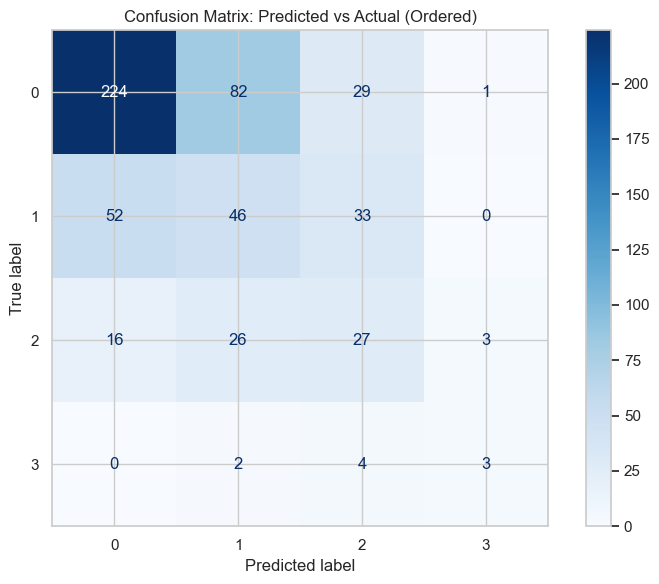

<Figure size 640x480 with 0 Axes>

In [115]:
svc_linear = svm.SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=42)
svc_linear.fit(X_train, y_train)
y_pred_svc = svc_linear.predict(X_test)

cv_results_SVC = cross_validate(
    svc_linear,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics,
)

display_professional_eval(
    y_test,
    y_pred_svc,
    cv_results_SVC,
)

In [120]:
y_pred = [y_pres_lg, y_pred_rf, y_pred_XG, y_pred_svc]
models = ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]

comparison = compare_models(y_test, y_pred, models)
display(comparison)

,Model,Accuracy,kappa,f1_Score
0,Logistic Regression,0.510949,0.201587,0.357141
1,Random Forest,0.580292,0.195984,0.375585
2,XGBoost,0.585766,0.274049,0.441787
3,SVM,0.547445,0.223392,0.434052
